# Прогноз: ML-основа только на Random Forest

В этой версии используется один ML-метод — Random Forest. Модель обучается на реальных точках и уверенных псевдометках по `geo_score`, затем строит итоговую карту перспективности. Оставлены только минимальные метрики: ROC-AUC, Average Precision, средние вероятности по классам и доля реальных точек в верхних 15% прогноза. Сохраняется только PNG.

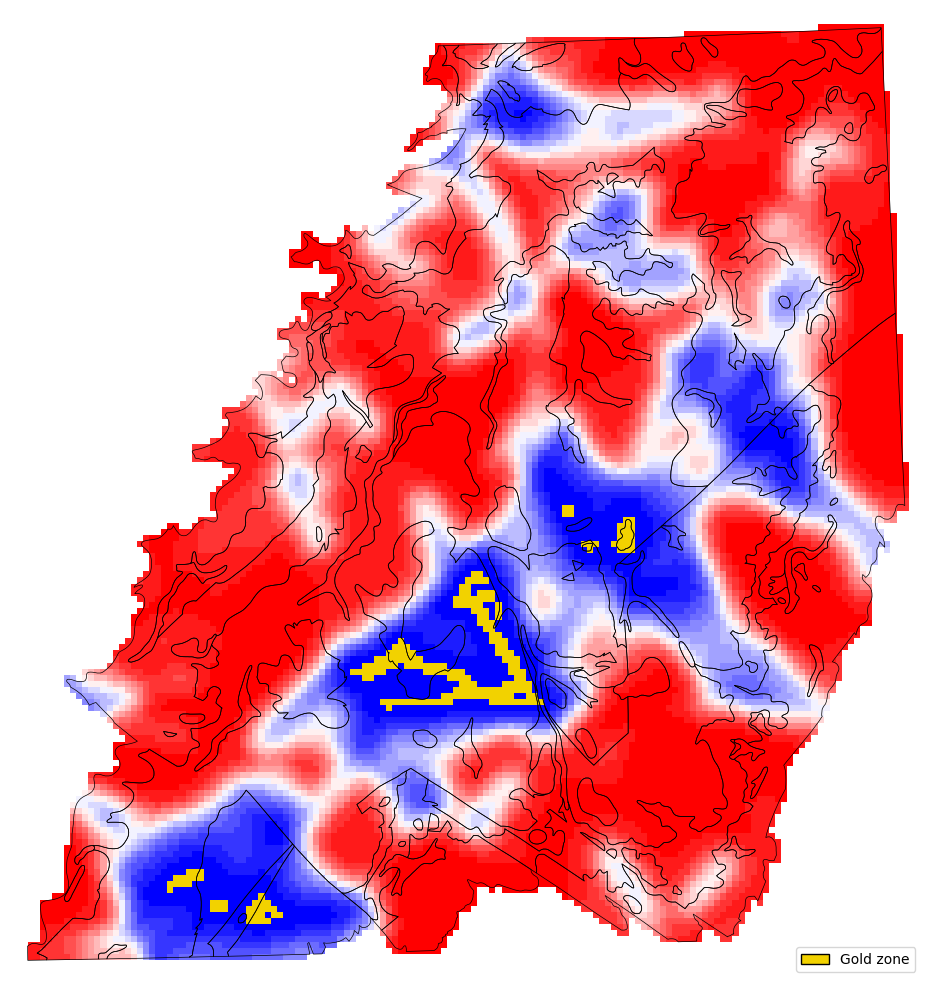

Готово. Сохранен PNG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\ml_png_result\forecast_ml_final.png
Ячеек с реальными точками: 68
Обучающих positive: 1004
Обучающих negative: 7809
Доля реальных точек в верхних 15% прогноза: 0.206


,Model,ROC_AUC,Average_Precision,Positive_mean_prob,Negative_mean_prob
0,Random Forest,0.994,0.984,0.945,0.031


In [1]:

import os
import re
import shutil
import tempfile
import warnings
from pathlib import Path
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from pyproj import CRS
from shapely.geometry import box
from shapely.ops import unary_union
from shapely.prepared import prep
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")

# =========================
# НАСТРОЙКИ
# =========================
CELL_SIZE = 500
RANDOM_STATE = 42

# ML — основа прогноза.
# Реальные точки + только уверенные псевдометки по geo_score.
USE_SUPERVISED = True
USE_PSEUDO_LABELS = True
PSEUDO_POS_Q = 0.94   # чуть больше положительных зон, чем в строгой версии
PSEUDO_NEG_Q = 0.50
MAX_NEG_PER_POS = 5
MIN_POS_CELLS = 20

RF_N_ESTIMATORS = 800
RF_MAX_DEPTH = 7
RF_MIN_SAMPLES_LEAF = 12
RF_MIN_SAMPLES_SPLIT = 20

# Сглаживание итоговой поверхности, чтобы карта была менее пятнистой.
SMOOTH_PASSES = 4

# Небольшая геологическая стабилизация, но ML остается основой.
GEO_STABILIZER_WEIGHT = 0.20

Q_FACIES = 0.78
Q_PALEO = 0.76
Q_STRUCT = 0.72
Q_MAGM = 0.42
Q_TECT1 = 0.74
Q_TECT2 = 0.74

N_DISPLAY_CLASSES = 20
SHOW_POINTS = False

# =========================
# ПУТИ
# =========================
def find_base_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path("/mnt/data/prog_zip"),
        Path("/mnt/data"),
        Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"),
    ]
    for base in candidates:
        shp_dir = base / "shp_dbf"
        if shp_dir.exists() and (shp_dir / "svita_new.shp").exists():
            return base

    for zip_path in [Path("/mnt/data/Прогноз.zip"), Path.cwd() / "Прогноз.zip"]:
        if zip_path.exists():
            unzip_dir = Path("/mnt/data/prog_zip") if str(zip_path).startswith("/mnt/data") else Path.cwd() / "prog_zip"
            unzip_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(unzip_dir)
            for base in [unzip_dir, *unzip_dir.rglob("*")]:
                shp_dir = base / "shp_dbf"
                if shp_dir.exists() and (shp_dir / "svita_new.shp").exists():
                    return base

    raise FileNotFoundError("Не найден каталог с shp_dbf. Проверь BASE_DIR или положи рядом Прогноз.zip.")

BASE_DIR = find_base_dir()
SHP_DIR = BASE_DIR / "shp_dbf"
OUT_DIR = BASE_DIR / "ml_png_result"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "forecast_ml_final.png"

# Временные алиасы нужны только для чтения shapefile с кириллическими именами.
# Они не сохраняются как результат.
TMP_ALIAS_DIR = Path(tempfile.mkdtemp(prefix="shp_aliases_"))

# =========================
# ФУНКЦИИ
# =========================
def normalize_01(values):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if finite.sum() == 0:
        return np.zeros_like(arr, dtype=float)
    mn = np.nanmin(arr[finite])
    mx = np.nanmax(arr[finite])
    if np.isclose(mx, mn):
        return np.full_like(arr, 0.5, dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)
    out[finite] = (arr[finite] - mn) / (mx - mn)
    return out

def robust_normalize_01(values, q_low=0.03, q_high=0.97):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if finite.sum() == 0:
        return np.zeros_like(arr, dtype=float)
    lo = np.nanquantile(arr[finite], q_low)
    hi = np.nanquantile(arr[finite], q_high)
    if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
        return normalize_01(arr)
    return np.clip((arr - lo) / (hi - lo), 0, 1)

def smooth_on_regular_grid(grid, value_col, shape, passes=1):
    try:
        from scipy.signal import convolve2d
    except Exception:
        return grid[value_col].to_numpy()
    arr = np.full(shape, np.nan, dtype=float)
    arr[grid["row"].to_numpy(), grid["col"].to_numpy()] = grid[value_col].to_numpy()
    kernel = np.array([[1.0, 1.2, 1.0], [1.2, 3.0, 1.2], [1.0, 1.2, 1.0]], dtype=float)
    smoothed = arr.copy()
    for _ in range(max(1, passes)):
        valid = np.isfinite(smoothed).astype(float)
        filled = np.nan_to_num(smoothed, nan=0.0)
        num = convolve2d(filled, kernel, mode="same", boundary="fill", fillvalue=0)
        den = convolve2d(valid, kernel, mode="same", boundary="fill", fillvalue=0)
        smoothed = np.where(den > 0, num / den, np.nan)
    return smoothed[grid["row"].to_numpy(), grid["col"].to_numpy()]

def local_max_mask(grid, value_col, shape):
    try:
        from scipy.ndimage import maximum_filter
    except Exception:
        vals = grid[value_col].to_numpy()
        thr = np.nanquantile(vals, 0.98)
        return vals >= thr
    arr = np.full(shape, np.nan, dtype=float)
    rows = grid["row"].to_numpy()
    cols = grid["col"].to_numpy()
    vals = grid[value_col].to_numpy()
    arr[rows, cols] = vals
    filled = np.nan_to_num(arr, nan=-9999.0)
    locmax = maximum_filter(filled, size=3, mode="nearest")
    return (np.isfinite(arr) & (filled >= locmax))[rows, cols]

def keep_large_components(grid, bool_col, shape, min_cells=4):
    try:
        from scipy import ndimage
    except Exception:
        return grid[bool_col].to_numpy().astype(bool)
    arr = np.zeros(shape, dtype=np.uint8)
    rows = grid["row"].to_numpy()
    cols = grid["col"].to_numpy()
    arr[rows, cols] = grid[bool_col].to_numpy().astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, _ = ndimage.label(arr, structure=structure)
    sizes = np.bincount(labeled.ravel())
    keep_ids = np.where(sizes >= min_cells)[0]
    keep = np.isin(labeled, keep_ids) & (labeled > 0)
    return keep[rows, cols]

def read_sidecar_proj4(shp_path: Path):
    sidecar = shp_path.with_name(shp_path.stem + "_shp.pj4")
    if sidecar.exists():
        txt = sidecar.read_text(encoding="utf-8", errors="ignore")
        m = re.search(r"pj4=(.+)", txt)
        if m:
            return m.group(1).strip()
    return None

def prepare_ascii_aliases(shp_dir: Path, alias_dir: Path):
    aliases, stems = {}, {}
    for name_b in os.listdir(os.fsencode(shp_dir)):
        if not name_b.endswith((b".shp", b".shx", b".dbf", b".prj", b".pj4")) or name_b.endswith(b"_shp.pj4"):
            continue
        base_b, ext_b = os.path.splitext(name_b)
        stems.setdefault(base_b, set()).add(ext_b)

    alias_idx = 0
    for base_b, exts in sorted(stems.items()):
        try:
            base_s = os.fsdecode(base_b)
            safe = all(ord(ch) < 128 and (ch.isalnum() or ch in "_-. ") for ch in base_s)
        except Exception:
            safe = False
            base_s = None

        if safe:
            aliases[base_s] = shp_dir / f"{base_s}.shp"
            continue

        alias = f"layer_{alias_idx:02d}"
        alias_idx += 1
        for ext_b in exts:
            src = os.path.join(os.fsencode(shp_dir), base_b + ext_b)
            dst = alias_dir / f"{alias}{os.fsdecode(ext_b)}"
            shutil.copyfile(src, dst)
        pj4_src = os.path.join(os.fsencode(shp_dir), base_b + b"_shp.pj4")
        if os.path.exists(pj4_src):
            shutil.copyfile(pj4_src, alias_dir / f"{alias}_shp.pj4")
        aliases[alias] = alias_dir / f"{alias}.shp"
    return aliases

def load_layer(path: Path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    if gdf.crs is None:
        proj4 = read_sidecar_proj4(path)
        if proj4:
            gdf = gdf.set_crs(CRS.from_proj4(proj4), allow_override=True)
    return gdf

def to_crs_safe(gdf, target_crs):
    if gdf.crs is None and target_crs is not None:
        return gdf.set_crs(target_crs, allow_override=True)
    if target_crs is None or gdf.crs == target_crs:
        return gdf
    return gdf.to_crs(target_crs)

def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    prepared_mask = prep(mask_union)
    minx, miny, maxx, maxy = mask.total_bounds
    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)
    rows = []
    cell_id = 0
    for r, y in enumerate(ys):
        for c, x in enumerate(xs):
            geom = box(x, y, x + cell_size, y + cell_size)
            if prepared_mask.intersects(geom):
                rows.append((cell_id, r, c, geom))
                cell_id += 1
    grid = gpd.GeoDataFrame(rows, columns=["cell_id", "row", "col", "geometry"], geometry="geometry", crs=mask.crs)
    return grid, mask_union, (len(ys), len(xs))

def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    d = np.empty(len(grid), dtype=float)
    for i, geom in enumerate(grid.geometry.values):
        d[i] = 0.0 if geom.intersects(source_union) else geom.distance(source_union)
    grid[name] = d
    return grid

def distance_to_proximity(distance, transform="sqrt", q=0.75):
    d = np.asarray(distance, dtype=float)
    d = np.clip(d, 0, None)
    if transform == "sqrt":
        t = np.sqrt(d)
    elif transform == "cbrt":
        t = np.cbrt(d)
    else:
        t = d
    scale = float(np.nanquantile(t, q))
    if not np.isfinite(scale) or scale <= 0:
        scale = max(float(np.nanmean(t)), 1.0)
    return np.clip(np.exp(-t / scale), 0, 1)

def collect_points(mask_crs, aliases):
    base_names = {"svita_new", "fasii", "glub_raz_nw", "glub_r_nw", "gr_dol_vp_poly", "kory", "dayki_buf"}
    layers = []
    for name, shp_path in aliases.items():
        if name in base_names:
            continue
        gdf = to_crs_safe(load_layer(shp_path), mask_crs)
        types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in types or "MultiPoint" in types:
            gdf = gdf.copy()
            gdf["source_layer"] = name
            layers.append(gdf)
    if not layers:
        return None
    pts = pd.concat(layers, ignore_index=True)
    return gpd.GeoDataFrame(pts, geometry="geometry", crs=mask_crs)

def make_display_classes(grid):
    disp = robust_normalize_01(grid["prospectivity"].to_numpy(), 0.02, 0.98)
    grid["display_score"] = disp
    bins = np.linspace(0, 1, N_DISPLAY_CLASSES + 1)
    grid["display_class"] = np.digitize(disp, bins[1:-1], right=False)
    return grid

def set_mask_extent(ax, mask):
    minx, miny, maxx, maxy = mask.total_bounds
    padx = (maxx - minx) * 0.02
    pady = (maxy - miny) * 0.02
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)

def mark_gold_zones(grid, shape, mask_union):
    q_best = float(grid["prospectivity"].quantile(0.97))
    q_support = float(grid["prospectivity"].quantile(0.88))
    q_local = float(grid["local_bonus"].quantile(0.97))
    q_coinc = float(grid["coincidence_score"].quantile(0.94))
    q_magm = float(grid["prox_magm"].quantile(0.90))
    q_tmagm = float(grid["tect_magm_intersection"].quantile(0.84))

    local_peak = local_max_mask(grid, "prospectivity", shape)
    mask_boundary = mask_union.boundary
    grid["dist_to_boundary"] = np.array([geom.distance(mask_boundary) for geom in grid.geometry])
    support_zone = grid["prospectivity"] >= q_support

    core_gold = (
        support_zone &
        local_peak &
        (grid["prospectivity"] >= q_best) &
        (
            ((grid["local_bonus"] >= q_local) & (grid["tect_magm_intersection"] >= q_tmagm)) |
            ((grid["coincidence_score"] >= q_coinc) & (grid["prox_magm"] >= q_magm))
        )
    )

    linear_gold = (
        support_zone &
        (grid["prospectivity"] >= float(grid["prospectivity"].quantile(0.94))) &
        (grid["prox_magm"] >= q_magm) &
        (grid["tect_magm_intersection"] >= q_tmagm) &
        (grid["coincidence_score"] >= q_coinc)
    )

    edge_linear_gold = linear_gold & (grid["dist_to_boundary"] <= CELL_SIZE * 0.75)
    grid["gold_seed"] = (core_gold | edge_linear_gold).astype(int)
    grid["gold_zone"] = keep_large_components(grid, "gold_seed", shape, min_cells=4).astype(int)
    return grid

def safe_binary_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    out = {
        "ROC_AUC": np.nan,
        "Average_Precision": np.nan,
        "Positive_mean_prob": np.nan,
        "Negative_mean_prob": np.nan,
    }
    if len(np.unique(y_true)) >= 2:
        out["ROC_AUC"] = float(roc_auc_score(y_true, y_prob))
        out["Average_Precision"] = float(average_precision_score(y_true, y_prob))
    if np.any(y_true == 1):
        out["Positive_mean_prob"] = float(np.mean(y_prob[y_true == 1]))
    if np.any(y_true == 0):
        out["Negative_mean_prob"] = float(np.mean(y_prob[y_true == 0]))
    return out

def plot_final(grid, mask, points, out_png):
    fig, ax = plt.subplots(figsize=(10, 10))
    bins = np.arange(N_DISPLAY_CLASSES + 1)
    norm = BoundaryNorm(bins, plt.cm.bwr_r.N)
    grid.plot(column="display_class", ax=ax, cmap="bwr_r", norm=norm, linewidth=0, legend=False)

    gold = grid[grid["gold_zone"] == 1]
    if len(gold) > 0:
        gold.plot(ax=ax, color="#f2d200", linewidth=0)

    mask.boundary.plot(ax=ax, color="black", linewidth=0.5)

    if SHOW_POINTS and points is not None and len(points) > 0:
        points.plot(ax=ax, color="yellow", markersize=8, edgecolor="black", linewidth=0.25)

    ax.legend(handles=[Patch(facecolor="#f2d200", edgecolor="black", label="Gold zone")], loc="lower right", frameon=True)
    set_mask_extent(ax, mask)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# =========================
# ЗАГРУЗКА ДАННЫХ
# =========================
aliases = prepare_ascii_aliases(SHP_DIR, TMP_ALIAS_DIR)

mask = load_layer(aliases["svita_new"])
facies = to_crs_safe(load_layer(aliases["fasii"]), mask.crs)
tect1 = to_crs_safe(load_layer(aliases["glub_raz_nw"]), mask.crs)
tect2 = to_crs_safe(load_layer(aliases["glub_r_nw"]), mask.crs)
paleo = to_crs_safe(load_layer(aliases["gr_dol_vp_poly"]), mask.crs)
struct = to_crs_safe(load_layer(aliases["kory"]), mask.crs)
magm = to_crs_safe(load_layer(aliases["dayki_buf"]), mask.crs)
points = collect_points(mask.crs, aliases)

# =========================
# СЕТКА И ПРИЗНАКИ
# =========================
grid, mask_union, grid_shape = build_grid(mask, CELL_SIZE)

for src, name in [
    (facies, "dist_facies"),
    (paleo, "dist_paleo"),
    (struct, "dist_struct"),
    (magm, "dist_magm"),
    (tect1, "dist_tect1"),
    (tect2, "dist_tect2"),
]:
    grid = add_distance_feature(grid, src, name)

grid["prox_facies"] = distance_to_proximity(grid["dist_facies"], "cbrt", Q_FACIES)
grid["prox_paleo"] = distance_to_proximity(grid["dist_paleo"], "cbrt", Q_PALEO)
grid["prox_struct"] = distance_to_proximity(grid["dist_struct"], "sqrt", Q_STRUCT)
grid["prox_magm"] = distance_to_proximity(grid["dist_magm"], "sqrt", Q_MAGM)
grid["prox_tect1"] = distance_to_proximity(grid["dist_tect1"], "cbrt", Q_TECT1)
grid["prox_tect2"] = distance_to_proximity(grid["dist_tect2"], "cbrt", Q_TECT2)

grid["tect_combo"] = 0.5 * (grid["prox_tect1"] + grid["prox_tect2"])
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = np.sqrt(grid["tect_combo"] * grid["prox_magm"])
grid["tect_struct_intersection"] = np.sqrt(grid["tect_combo"] * grid["prox_struct"])
grid["paleo_struct_intersection"] = np.sqrt(grid["prox_paleo"] * grid["prox_struct"])

combo_core = (
    np.clip(grid["tect_combo"], 0, 1)
    * np.clip(0.55 * grid["prox_magm"] + 0.45 * grid["prox_struct"], 0, 1)
    * np.clip(0.60 * grid["prox_paleo"] + 0.40 * grid["prox_facies"], 0, 1)
)
grid["coincidence_score"] = robust_normalize_01(np.sqrt(np.clip(combo_core, 0, 1)), 0.02, 0.98)

tect_support = 0.40 * grid["prox_magm"] + 0.35 * grid["prox_struct"] + 0.25 * grid["prox_paleo"]
grid["tect_only_penalty"] = robust_normalize_01(np.clip(grid["tect_combo"] - tect_support, 0, 1), 0.02, 0.98)

# =========================
# GEO_SCORE ДЛЯ ПСЕВДОМЕТОК
# =========================
grid["geo_score_raw"] = (
    0.14 * grid["prox_tect1"] +
    0.14 * grid["prox_tect2"] +
    0.14 * grid["prox_paleo"] +
    0.11 * grid["prox_struct"] +
    0.08 * grid["prox_facies"] +
    0.08 * grid["prox_magm"] +
    0.08 * grid["tect_intersection"] +
    0.08 * grid["tect_magm_intersection"] +
    0.05 * grid["tect_struct_intersection"] +
    0.04 * grid["paleo_struct_intersection"] +
    0.10 * grid["coincidence_score"] -
    0.08 * grid["tect_only_penalty"]
)
grid["geo_score"] = robust_normalize_01(grid["geo_score_raw"], 0.02, 0.98)
grid["geo_score_sm"] = robust_normalize_01(smooth_on_regular_grid(grid, "geo_score", grid_shape, passes=2), 0.02, 0.98)

# =========================
# ML: RANDOM FOREST
# =========================
# geo_score НЕ входит в признаки. Он используется только для выбора уверенных обучающих ячеек.
feature_cols = [
    "prox_facies", "prox_paleo", "prox_struct", "prox_magm",
    "prox_tect1", "prox_tect2", "tect_combo", "tect_intersection",
    "tect_magm_intersection", "tect_struct_intersection",
    "paleo_struct_intersection", "coincidence_score", "tect_only_penalty"
]

grid["target_ml"] = np.nan

if USE_SUPERVISED and points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(points[["geometry"]], grid[["cell_id", "geometry"]], how="left", predicate="within")
    except Exception:
        joined = gpd.sjoin(points[["geometry"]], grid[["cell_id", "geometry"]], how="left", op="within")
    positive_cells = joined["cell_id"].dropna().astype(int).unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target_ml"] = 1
else:
    positive_cells = []

if USE_PSEUDO_LABELS:
    q_pos = float(grid["geo_score_sm"].quantile(PSEUDO_POS_Q))
    q_neg = float(grid["geo_score_sm"].quantile(PSEUDO_NEG_Q))
    grid.loc[(grid["geo_score_sm"] >= q_pos) & (grid["target_ml"].isna()), "target_ml"] = 1
    grid.loc[(grid["geo_score_sm"] <= q_neg) & (grid["target_ml"].isna()), "target_ml"] = 0

train = grid.dropna(subset=["target_ml"]).copy()
pos_n = int((train["target_ml"] == 1).sum())
neg_n = int((train["target_ml"] == 0).sum())

if pos_n >= MIN_POS_CELLS and neg_n > 0:
    pos_train = train[train["target_ml"] == 1]
    neg_train = train[train["target_ml"] == 0]
    neg_train = neg_train.sample(n=min(len(neg_train), pos_n * MAX_NEG_PER_POS), random_state=RANDOM_STATE)
    train_bal = pd.concat([pos_train, neg_train], ignore_index=True)

    X = train_bal[feature_cols].fillna(0).to_numpy()
    y = train_bal["target_ml"].astype(int).to_numpy()
    X_all = grid[feature_cols].fillna(0).to_numpy()

    # Минимальная проверка качества на отложенной части pseudo-label выборки.
    # Это не "истинная" геологическая точность, а контроль, различает ли RF
    # обучающие перспективные и фоновые ячейки.
    metrics_rows = []
    if len(np.unique(y)) == 2 and min(np.bincount(y)) >= 5:
        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
        )

        rf_val = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            max_depth=RF_MAX_DEPTH,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            min_samples_split=RF_MIN_SAMPLES_SPLIT,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        rf_val.fit(X_tr, y_tr)
        rf_val_prob = rf_val.predict_proba(X_val)[:, 1]
        rf_m = safe_binary_metrics(y_val, rf_val_prob)
        rf_m["Model"] = "Random Forest"
        metrics_rows.append(rf_m)

    # Финальная модель обучается на всей подготовленной обучающей выборке.
    rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X, y)

    # Основной ML-слой: вероятность перспективности по Random Forest.
    grid["rf_score"] = robust_normalize_01(rf.predict_proba(X_all)[:, 1], 0.02, 0.98)
    grid["ml_score"] = grid["rf_score"]
else:
    # Если обучающих данных недостаточно, код не падает, а использует geo_score как резерв.
    grid["rf_score"] = grid["geo_score_sm"]
    grid["ml_score"] = grid["geo_score_sm"]

grid["ml_score_sm"] = robust_normalize_01(smooth_on_regular_grid(grid, "ml_score", grid_shape, passes=SMOOTH_PASSES), 0.02, 0.98)

# =========================
# ИТОГОВАЯ ПОВЕРХНОСТЬ
# =========================
grid["local_bonus"] = robust_normalize_01(
    0.38 * grid["tect_intersection"] +
    0.37 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"],
    0.02, 0.98,
)

w_geo = float(np.clip(GEO_STABILIZER_WEIGHT, 0, 1))
grid["prospectivity_raw"] = (1.0 - w_geo) * grid["ml_score_sm"].to_numpy() + w_geo * grid["geo_score_sm"].to_numpy()
grid["prospectivity_raw_sm"] = smooth_on_regular_grid(grid, "prospectivity_raw", grid_shape, passes=2)
grid["prospectivity"] = robust_normalize_01(grid["prospectivity_raw_sm"], 0.02, 0.98)
grid["prognoz"] = 1.0 - grid["prospectivity"]

grid = make_display_classes(grid)
grid = mark_gold_zones(grid, grid_shape, mask_union)

# =========================
# МИНИМАЛЬНЫЕ МЕТРИКИ И СОХРАНЕНИЕ PNG
# =========================
# Метрика попадания известных точек в верхние 15% итогового прогноза.
if len(positive_cells) > 0:
    top15_thr = float(grid["prospectivity"].quantile(0.85))
    real_point_cells = grid[grid["cell_id"].isin(positive_cells)].copy()
    point_top15_coverage = float((real_point_cells["prospectivity"] >= top15_thr).mean()) if len(real_point_cells) else np.nan
else:
    point_top15_coverage = np.nan

plot_final(grid, mask, points, OUT_PNG)

print("Готово. Сохранен PNG:", OUT_PNG)
print("Ячеек с реальными точками:", len(positive_cells))
print("Обучающих positive:", int((grid["target_ml"] == 1).sum()))
print("Обучающих negative:", int((grid["target_ml"] == 0).sum()))
print("Доля реальных точек в верхних 15% прогноза:", round(point_top15_coverage, 3) if np.isfinite(point_top15_coverage) else "нет данных")

if "metrics_rows" in globals() and len(metrics_rows) > 0:
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df = metrics_df[["Model", "ROC_AUC", "Average_Precision", "Positive_mean_prob", "Negative_mean_prob"]]
    display(metrics_df.round(3))
else:
    print("Метрики ROC-AUC/AP не рассчитаны: слишком мало классов или обучающих примеров.")

